<a href="https://colab.research.google.com/github/KHUSHINATARAJ/ML_LAB_6TH_SEM/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
housing= pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [2]:
def find_correlation(housing_numeric):
  # computing standard correlation coefficient
  corr_matrix = housing_numeric.corr()
  # fetch and return attribute correlates
  # with the median housing value
  return corr_matrix["median_house_value"].sort_values(
    ascending=False)

# drop ocean_proximity column
housing_numeric = housing.drop("ocean_proximity", axis=1)
# find correlation coefficient
cor_coef = find_correlation(housing_numeric)
print("Correlation Coefficient::", cor_coef)

Correlation Coefficient:: median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


<Axes: xlabel='median_income', ylabel='median_house_value'>

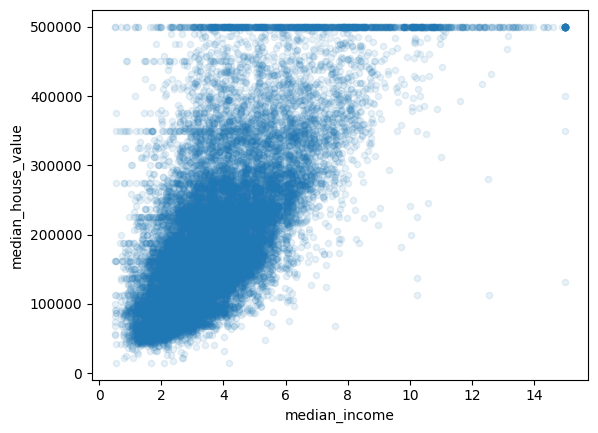

In [3]:
# scatter plot diagram
housing.plot(kind='scatter',
             x="median_income", y="median_house_value",
             alpha=0.1)

array([[<Axes: title={'center': 'median_income'}>]], dtype=object)

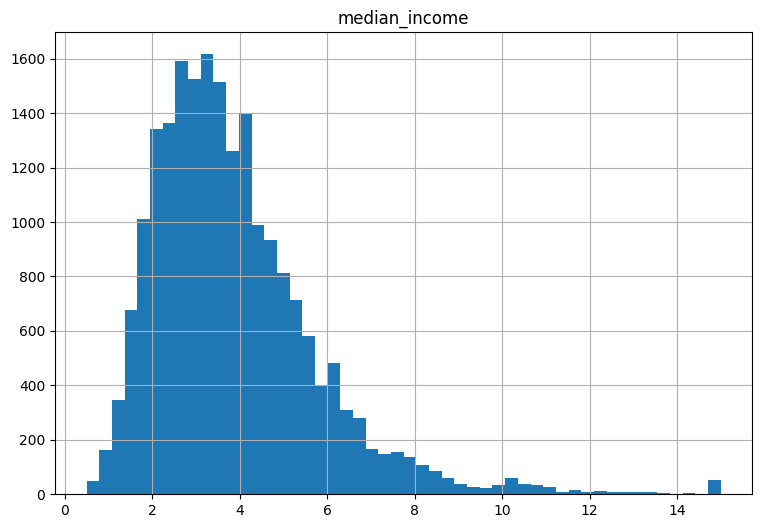

In [4]:
housing.hist(column='median_income',
             bins=50, figsize=(9,6))

<Axes: >

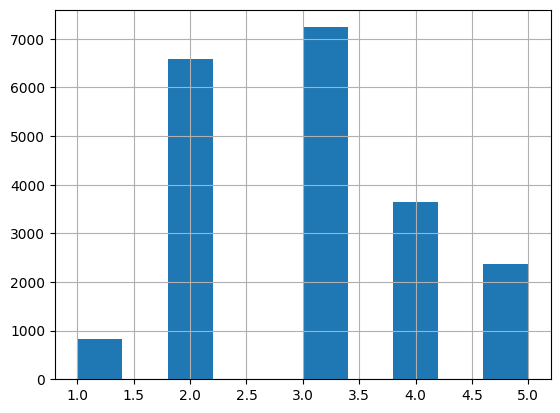

In [5]:
import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error

def fetch_housing_data():
  return pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")

def set_income_category(housing_selected):
    # set income category based on median income
    housing_selected["income_cat"] = pd.cut(housing_selected["median_income"],
                                            bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                            labels=[1, 2, 3, 4, 5])
    return housing_selected

def get_strat_train_test_dataset(housing_selected):
    # stratified sampling
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    housing_split = split.split(housing_selected, housing_selected["income_cat"])
    # get train and test dataset
    for train_index, test_index in housing_split:
        train_set = housing_selected.loc[train_index]
        test_set = housing_selected.loc[test_index]

    # drop income_category from train and test dataset
    for set_ in (train_set, test_set):
        set_.drop("income_cat", axis=1, inplace=True)

    return train_set, test_set

def sprt_train_and_label_set(train_set):
    # drop median_house_value from training data
    housing_tr = train_set.drop("median_house_value", axis=1)
    # create a new dataframe with median_house_value
    housing_labels = train_set["median_house_value"].copy()
    return housing_tr, housing_labels

def get_rmse(housing_labels, predicted_data):
    # get mean squared error to analyse prediction error
    mse = mean_squared_error(housing_labels, predicted_data)
    rmse = np.sqrt(mse)
    return rmse

# get housing data
housing = fetch_housing_data()
# copy median_income and median_house_value
housing_selected = housing[['median_income', 'median_house_value']].copy()
# set income category based on median_icome
housing_selected = set_income_category(housing_selected)
# stratified sampling
train_set, test_set = get_strat_train_test_dataset(housing_selected)
# seperate label and data from training set
housing_tr, housing_labels = sprt_train_and_label_set(train_set)

In [7]:
from sklearn.linear_model import LinearRegression
# linear regression model for best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_tr, housing_labels)

# sample data to test from training set
sample_data = housing_tr.iloc[:5]
sample_labels = housing_labels.iloc[:5]

# predict the median_house_value
predicted_data = lin_reg.predict(sample_data)
print("Predicted Price:", predicted_data)
print("Actual Price:", list(sample_labels))

Predicted Price: [135958.75805364 309735.008975   165232.3998617  138162.41971241
 232903.1766333 ]
Actual Price: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [8]:
# pass the training data and identify the prediction error
predicted_data = lin_reg.predict(housing_tr)
lin_rmse = get_rmse(housing_labels, predicted_data)
print("root mean square error:", lin_rmse)

root mean square error: 84056.18763327331


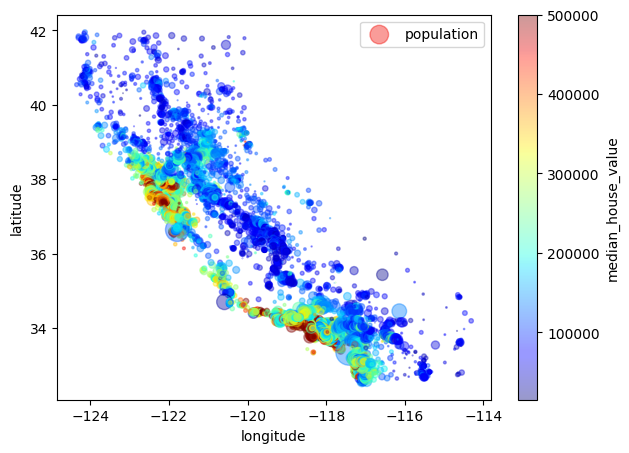

In [9]:
import matplotlib.pyplot as plt
# plot
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(7,5),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,)
plt.legend()

In [10]:
from sklearn.impute import SimpleImputer

# drop ocean_proximity column
housing_num = housing.drop("ocean_proximity", axis=1)

# imputer instance
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)
housing_imputer = imputer.transform(housing_num)
print("Imputer return data type:", type(housing_imputer))

# convert back to pandas dataframe
housing_new = pd.DataFrame(
    housing_imputer, columns=housing_num.columns, index=housing_num.index)
print("New Housing Dataset:")
print(housing_new.info())

Imputer return data type: <class 'numpy.ndarray'>
New Housing Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def transformation_pipeline():
    # pipeline execution
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('std_scaler', StandardScaler())
    ])
    return num_pipeline


# get housing data
housing = fetch_housing_data()
# set income category based on median_icome
housing = set_income_category(housing)
# stratified sampling
train_set, test_set = get_strat_train_test_dataset(housing)
# seperate label and data from training set
housing_tr, housing_labels = sprt_train_and_label_set(train_set)
# drop ocean_proximity
housing_num = housing_tr.drop("ocean_proximity", axis=1)
# numeric pipeline execution
num_pipeline = transformation_pipeline()
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [12]:
from sklearn.linear_model import LinearRegression

# linear regression model to identify best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_num_tr, housing_labels)
# pass the prepared data and predict the housing price
predicted_data = lin_reg.predict(housing_num_tr)
# pass the predicted data and identify the prediction error
lin_rmse = get_rmse(housing_labels, predicted_data)
print("Linear Regression Prediction error:", lin_rmse)

Linear Regression Prediction error: 69957.72079714121


In [13]:
housing[["ocean_proximity"]].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [14]:
from sklearn.preprocessing import OneHotEncoder

# fetch ocean_proximity
housing_cat = housing[["ocean_proximity"]]
# one hot encoder
cat_encoder = OneHotEncoder()
housing_cat_encoder = cat_encoder.fit_transform(housing_cat)
# convert sparse matrix to array to dispaly the result
result = housing_cat_encoder.toarray()
print("Data:")
print(result)
category_list = cat_encoder.categories_
print("Category List::", category_list)

Data:
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Category List:: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing_tr)

In [16]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


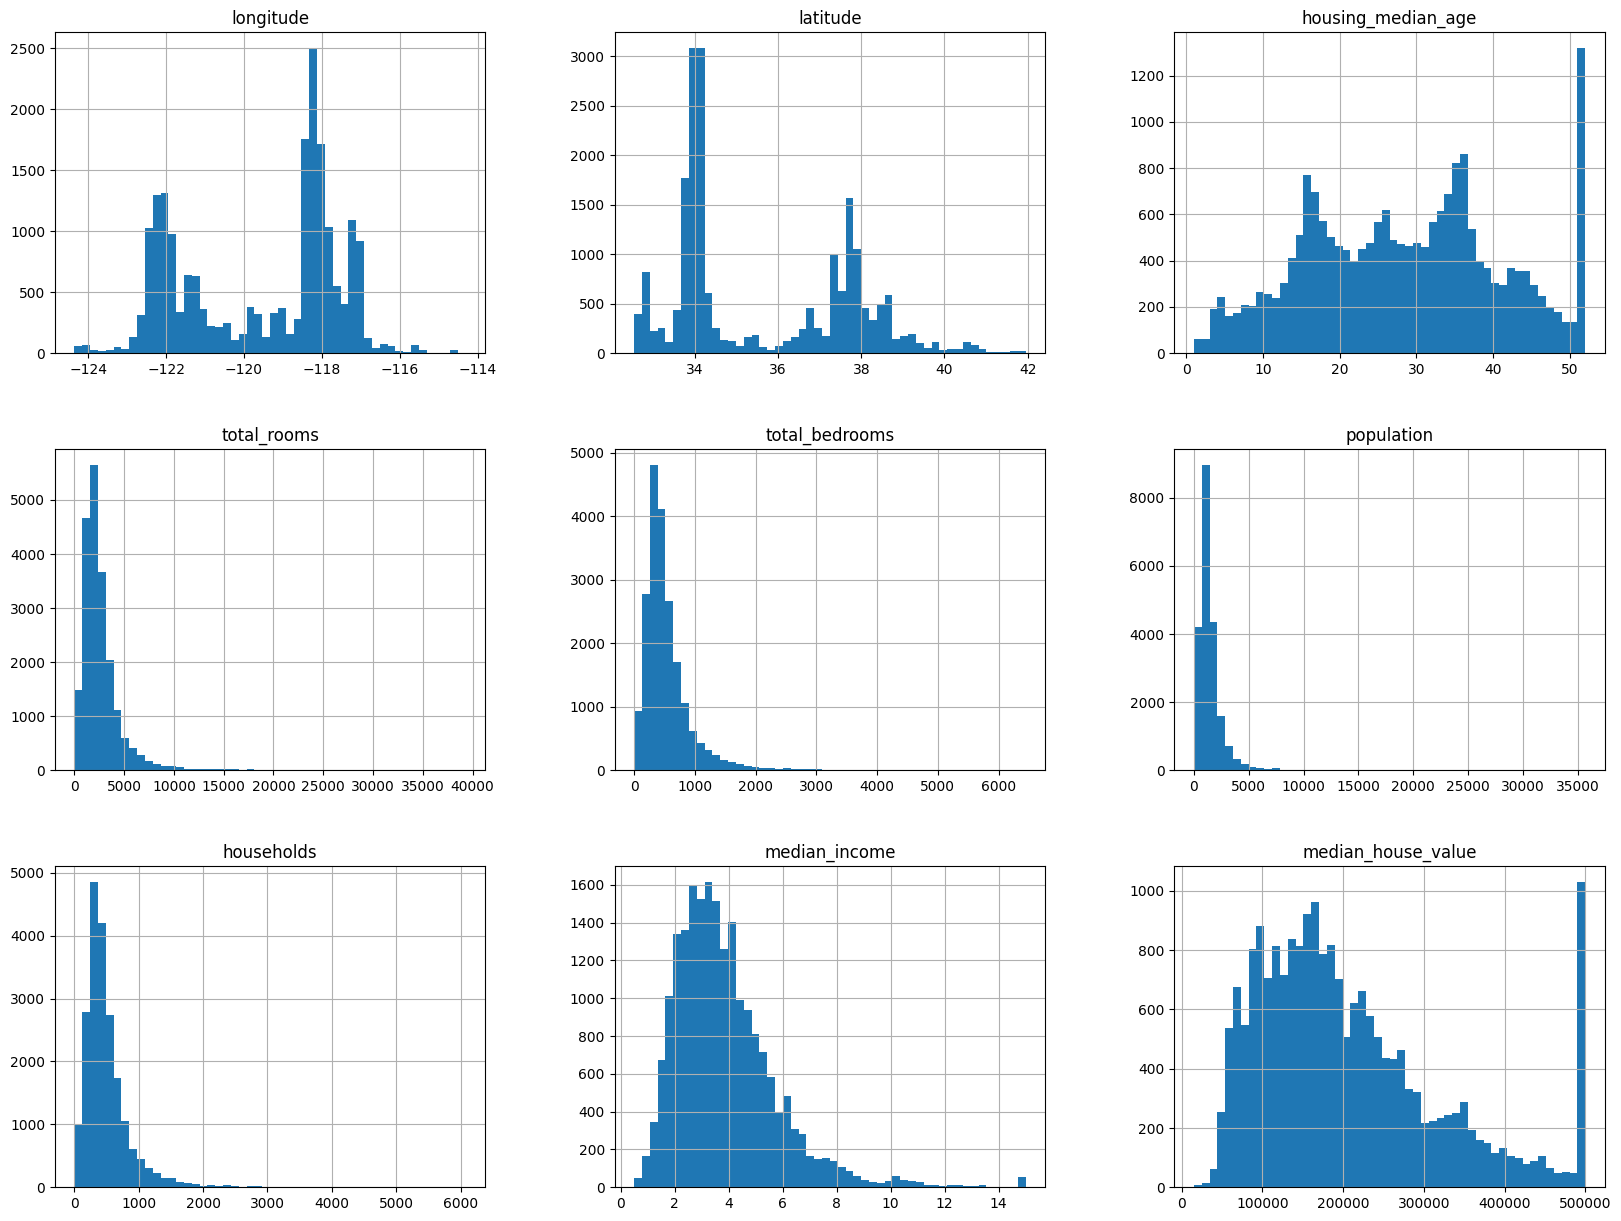

In [17]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix,households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X, y=None):
    rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
    population_per_household = X[:, population_ix] / X[:, households_ix]
    bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
    return np.c_[X, rooms_per_household, population_per_household,
                 bedrooms_per_room]

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


def transformation_pipeline():
    # pipeline execution
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler())
    ])
    return num_pipeline

def complete_pipeline(num_pipeline, num_attribs, cat_attribs):
    full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),])
    return full_pipeline


# numeric pipeline execution
num_pipeline = transformation_pipeline()
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
# pipeline execution of numeric and column attribute
full_pipeline = complete_pipeline(num_pipeline, num_attribs, cat_attribs)
housing_prepared = full_pipeline.fit_transform(housing_tr)

In [20]:
# linear regression model to identify best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
# pass the prepared data and predict the housing price
predicted_data = lin_reg.predict(housing_prepared)
# pass the predicted data and identify the prediction error
lin_rmse = get_rmse(housing_labels, predicted_data)
print("Linear Regression Prediction error:", lin_rmse)

Linear Regression Prediction error: 68627.87390018745


In [ ]:
#10 QUESTIONS !!

Dataset Loaded Successfully!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

DATA INFO:
<class 'pandas.core.frame.DataFram

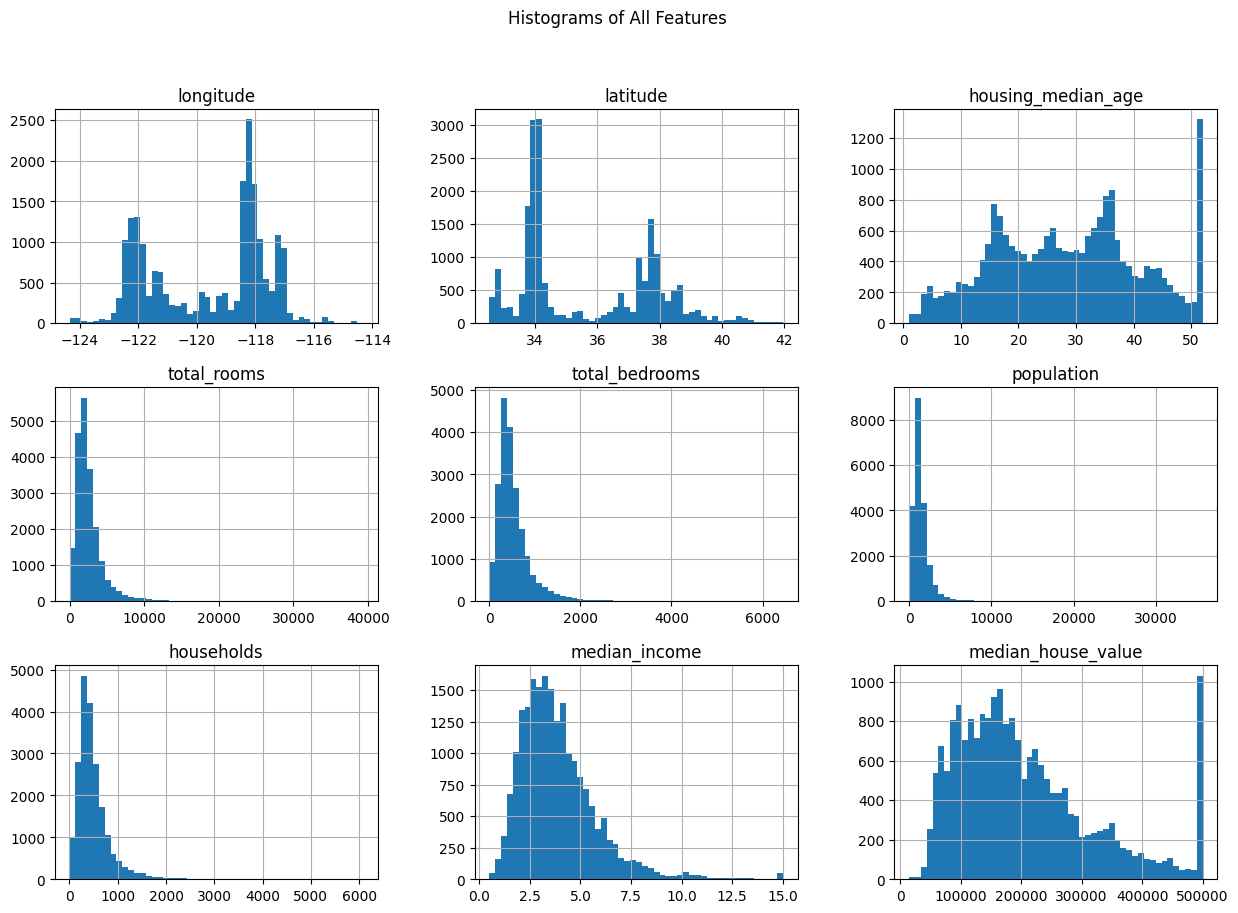


Stratified Split Done!


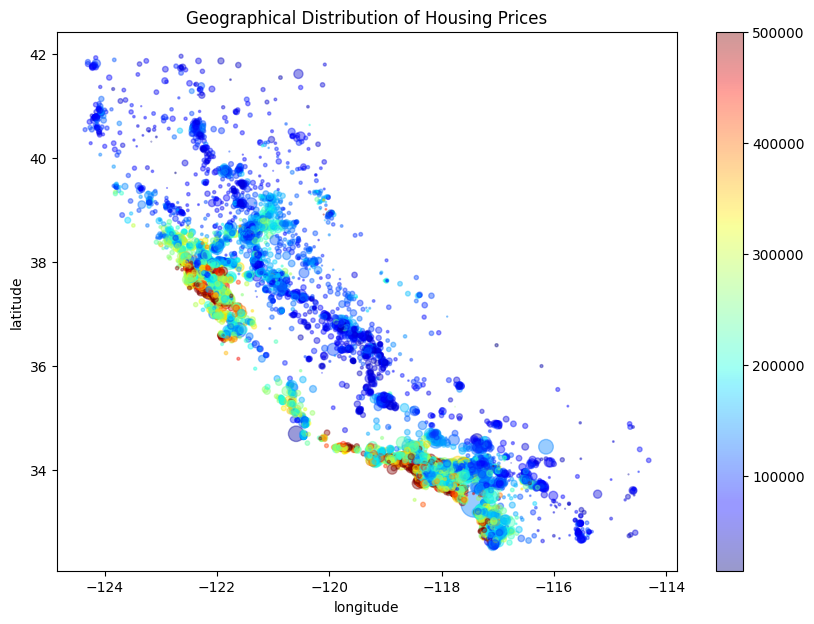

ValueError: could not convert string to float: 'INLAND'

In [21]:
# ================================
# STEP 1: Import Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# ================================
# STEP 2: Load Dataset
# ================================

url = "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv"

housing = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print(housing.head())


# ================================
# STEP 3: Info and Describe
# ================================

print("\nDATA INFO:")
housing.info()

print("\nDATA DESCRIPTION:")
print(housing.describe())


# ================================
# STEP 4: Plot Histograms
# ================================

housing.hist(bins=50, figsize=(15,10))
plt.suptitle("Histograms of All Features")
plt.show()


# ================================
# STEP 5: Create Income Category
# (For Stratified Sampling)
# ================================

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0,1.5,3,4.5,6,np.inf],
    labels=[1,2,3,4,5]
)


# ================================
# STEP 6: Stratified Train-Test Split
# ================================

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in split.split(housing, housing["income_cat"]):
    strat_train = housing.loc[train_idx]
    strat_test = housing.loc[test_idx]


# Remove income_cat column
for data in (strat_train, strat_test):
    data.drop("income_cat", axis=1, inplace=True)


print("\nStratified Split Done!")


# ================================
# STEP 7: Geographical Visualization
# ================================

strat_train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=strat_train["population"]/100,
    c=strat_train["median_house_value"],
    cmap="jet",
    colorbar=True,
    figsize=(10,7)
)

plt.title("Geographical Distribution of Housing Prices")
plt.show()


# ================================
# STEP 8: Correlation Analysis
# ================================

corr_matrix = strat_train.corr()

print("\nCorrelation with Median House Value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))


# ================================
# STEP 9: Feature Engineering
# ================================

strat_train["rooms_per_household"] = strat_train["total_rooms"]/strat_train["households"]

strat_train["bedrooms_per_room"] = strat_train["total_bedrooms"]/strat_train["total_rooms"]

strat_train["population_per_household"] = strat_train["population"]/strat_train["households"]


# ================================
# STEP 10: Prepare Data
# ================================

housing = strat_train.drop("median_house_value", axis=1)
housing_labels = strat_train["median_house_value"]

num_features = housing.drop("ocean_proximity", axis=1).columns
cat_features = ["ocean_proximity"]


# ================================
# STEP 11: Numerical Pipeline
# ================================

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ================================
# STEP 12: Full Pipeline
# ================================

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", OneHotEncoder(), cat_features)
])


# ================================
# STEP 13: Apply Pipeline
# ================================

housing_prepared = full_pipeline.fit_transform(housing)

print("\nData Preprocessing Complete!")
print("Prepared Data Shape:", housing_prepared.shape)


# ================================
# STEP 14: Train Model
# ================================

model = LinearRegression()

model.fit(housing_prepared, housing_labels)

print("\nModel Training Completed!")


# ================================
# STEP 15: Prepare Test Data
# ================================

X_test = strat_test.drop("median_house_value", axis=1)
y_test = strat_test["median_house_value"]

X_test_prepared = full_pipeline.transform(X_test)


# ================================
# STEP 16: Predictions
# ================================

final_predictions = model.predict(X_test_prepared)


# ================================
# STEP 17: Model Evaluation
# ================================

mse = mean_squared_error(y_test, final_predictions)
rmse = np.sqrt(mse)

print("\nMODEL PERFORMANCE:")
print("RMSE:", rmse)


# ================================
# STEP 18: Actual vs Predicted Plot
# ================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, final_predictions, alpha=0.3)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.plot([0,500000],[0,500000],'r')
plt.show()


# ================================
# FINAL MESSAGE
# ================================

print("\n----- PROJECT COMPLETED SUCCESSFULLY -----")
print("You have implemented full ML pipeline!")
